# Module 6 Notebook

<a target="_blank" href="https://colab.research.google.com/github/dannys0n/CS394-MyModulesRepo/blob/main/notebooks/06/generate_synthetic_voronoi_seeds.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://github.com/dannys0n/CS394-MyModulesRepo/tree/main/notebooks/06/generate_synthetic_voronoi_seeds.ipynb">
  <img src="https://img.shields.io/badge/Download_.ipynb-blue" alt="Download .ipynb"/>
</a>

# Generate Synthetic Training Data (Voronoi Seed Centers for Sharding)

This notebook generates a synthetic dataset for fine-tuning a chat model to do **seed placement** for a deterministic sharding algorithm (e.g., a Voronoi partition on a grid).

**Task to learn**
- **Input (user):** map aspect ratio + `k` (num of regions/servers availiable) + a list of weighted hotspots (x, y, weight, radius).
- **Output (assistant):** exactly `k` seed centers (x, y) in `[0,1]` as JSON.

**Diversity dimensions used during generation**
- `aspect_ratio` (world width/height)
- `k` (number of regions/servers)
- hotspot count
- hotspot **weight profile** (Dirichlet α: uniform-ish / balanced / spiky)
- hotspot **radius profile** (small / medium / large)
- hotspot positions are sampled uniformly in the unit square


## Simple constraints + quality gate (to avoid ugly Voronoi partitions)
The model still outputs **seed centers only**, but generation enforces a small set of checks and retries if a sample fails:

- **Min center spacing:** reject if any pair of centers is too close.
- **Voronoi area imbalance:** build a quick discrete Voronoi on a coarse grid and reject extreme max/min region area ratios.
- **Hotspot coverage:** ensure the top-weight hotspots have a nearby center.

These checks are to significantly reduce sliver regions and giant wedges while keeping the task and outputs unchanged.


## Data generation settings

In [43]:
NUM_TRAIN_EXAMPLES = 1000 # @param {type:"number"}
NUM_VAL_EXAMPLES = 150 # @param {type:"number"}
NUM_TEST_EXAMPLES = 15 # @param {type:"number"}

TEMPERATURE = 0.2 # @param {type:"number"}

BATCH_SIZE = 4 # @param {type:"number"}
MAX_RETRIES = 6 # @param {type:"number"}
RETRY_BACKOFF_SECONDS = 2.0 # @param {type:"number"}

DATA_FOLDER = "./.data/generated"
!mkdir -p {DATA_FOLDER}

DATAGEN_URL = "https://openrouter.ai/api/v1"

DATAGEN_MODEL = "openai/gpt-5.1-chat"


## Persistence (Colab)
Write outputs to Google Drive so long runs survive runtime resets.

In [44]:
import sys
import os

if 'google.colab' in sys.modules:
  from google.colab import drive  # type: ignore
  drive.mount('/content/drive')

  # Base project folder (user-requested)
  BASE_DIR = "/content/drive/MyDrive/cs394_voronoi_seeds"

  # Default generation output folder (created if needed)
  DEFAULT_DATA_FOLDER = os.path.join(BASE_DIR, ".data", "generated")

  # Notebook checkpoint folder (fallback search for existing data)
  CHECKPOINT_DIR = os.path.join(BASE_DIR, ".ipynb_checkpoints")

  # Use DEFAULT_DATA_FOLDER for new output; resume logic may override later if it finds existing files elsewhere.
  DATA_FOLDER = DEFAULT_DATA_FOLDER
  os.makedirs(DATA_FOLDER, exist_ok=True)

  print("BASE_DIR =", BASE_DIR)
  print("DATA_FOLDER (default) =", DATA_FOLDER)
  print("CHECKPOINT_DIR =", CHECKPOINT_DIR)
else:
  print("Not running in Colab; using existing DATA_FOLDER =", DATA_FOLDER)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR = /content/drive/MyDrive/cs394_voronoi_seeds
DATA_FOLDER (default) = /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated
CHECKPOINT_DIR = /content/drive/MyDrive/cs394_voronoi_seeds/.ipynb_checkpoints


## Manual resume (upload existing JSONL)
upload existing `train*.jsonl`, `valid*.jsonl`, `test*.jsonl` into Colab, then this notebook will copy them into Drive and resume appending.


In [45]:
import sys
if 'google.colab' in sys.modules:
  from google.colab import files  # type: ignore
  uploaded = files.upload()  # choose files from your machine
  print("Uploaded:", list(uploaded.keys()))
else:
  print("Not running in Colab.")


Saving train.jsonl to train.jsonl
Uploaded: ['train.jsonl']


In [46]:
import os, glob, shutil

# Settings for manual resume
SEED_FROM_UPLOADED_FILES = True
OVERWRITE_DRIVE_WITH_UPLOAD = True  # set False to keep existing Drive file if it already exists

def _pick_uploaded(split: str) -> str | None:
  # Look in /content for uploaded files matching common patterns
  patterns = [
    f"/content/{split}.jsonl",
    f"/content/{split}_*.jsonl",
    f"/content/{split}-*.jsonl",
    f"/content/{split}*.jsonl",
  ]
  candidates = []
  for pat in patterns:
    candidates.extend(glob.glob(pat))
  candidates = [c for c in candidates if os.path.isfile(c)]
  if not candidates:
    return None
  # Prefer newest upload
  candidates.sort(key=lambda p: os.path.getmtime(p), reverse=True)
  return candidates[0]

def seed_drive_from_upload():
  if not SEED_FROM_UPLOADED_FILES:
    print("SEED_FROM_UPLOADED_FILES=False; skipping.")
    return

  # Fixed filenames in Drive (simple + stable)
  train_dst = os.path.join(DATA_FOLDER, "train.jsonl")
  valid_dst = os.path.join(DATA_FOLDER, "valid.jsonl")
  test_dst  = os.path.join(DATA_FOLDER, "test.jsonl")

  mapping = {
    "train": (train_dst, _pick_uploaded("train")),
    "valid": (valid_dst, _pick_uploaded("valid")),
    "test":  (test_dst,  _pick_uploaded("test")),
  }

  for split, (dst, src) in mapping.items():
    if src is None:
      print(f"No uploaded {split}*.jsonl found in /content; leaving {dst} as-is.")
      continue
    if os.path.exists(dst) and not OVERWRITE_DRIVE_WITH_UPLOAD:
      print(f"Drive file exists and overwrite disabled; keeping {dst}")
      continue
    shutil.copy2(src, dst)
    print(f"Seeded {split}: {src} -> {dst}")

# Run seeding now (safe to re-run)
seed_drive_from_upload()


Seeded train: /content/train.jsonl -> /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/train.jsonl
No uploaded valid*.jsonl found in /content; leaving /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/valid.jsonl as-is.
No uploaded test*.jsonl found in /content; leaving /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/test.jsonl as-is.


## Dataset diversity

In [47]:
# Diversity dimensions
# 1) aspect_ratio (world width / height)
# 2) k (number of availiable servers)
# 3) hotspot count
# 4) hotspot weight profile (Dirichlet alpha)
# 5) hotspot radius profile
#
# Note: aspect_ratio is a true ratio (>0). It is NOT normalized to [0,1].

ASPECT_RATIO_VALUES = [0.5, 0.75, 1.0, 1.5, 2.0]
ASPECT_RATIO_WEIGHTS = [0.10, 0.15, 0.40, 0.25, 0.10]

K_VALUES = [4, 6, 8, 12, 16]
K_WEIGHTS = [0.15, 0.20, 0.30, 0.25, 0.10]

HOTSPOT_COUNT_VALUES = [3, 5, 8, 12]
HOTSPOT_COUNT_WEIGHTS = [0.25, 0.35, 0.25, 0.15]

WEIGHT_PROFILES = [
  ("uniformish", 3.0),   # weights closer together
  ("balanced",   1.2),
  ("spiky",      0.5),   # one or few hotspots dominate
]
WEIGHT_PROFILE_WEIGHTS = [0.30, 0.45, 0.25]

RADIUS_PROFILES = [
  ("small",  (0.02, 0.05)),
  ("medium", (0.05, 0.10)),
  ("large",  (0.10, 0.18)),
]
RADIUS_PROFILE_WEIGHTS = [0.30, 0.50, 0.20]


## Model for structured output

In [48]:
from pydantic import BaseModel, Field

class Point01(BaseModel):
  x: float = Field(ge=0.0, le=1.0)
  y: float = Field(ge=0.0, le=1.0)

class SeedCenters(BaseModel):
  centers: list[Point01]

# --- Batch structured output when BATCH_SIZE > 1 ---
class SeedCentersBatch(BaseModel):
  outputs: list[SeedCenters]


## Get OpenRouter API key

In [49]:
import sys
import os
from dotenv import load_dotenv

if 'google.colab' in sys.modules:
  from google.colab import userdata # type:ignore
  os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')
else:
  load_dotenv()

## Conversation generation functions

In [50]:
import openai
import os
import time
import random
import json
import numpy as np

client = openai.OpenAI(
  base_url=DATAGEN_URL,
  api_key=os.environ.get("OPENROUTER_API_KEY"),
)

# constraints
MIN_CENTER_DIST_PROMPT = 0.07   # stated to the model
MIN_CENTER_DIST_GATE   = 0.06   # enforced in code (slightly looser than prompt)
HOTSPOT_COVER_DIST     = 0.12   # at least one center within this distance of each top hotspot
TOP_HOTSPOTS_TO_COVER  = 2      # cover top-N hotspots by weight
MAX_AREA_RATIO         = 12.0   # reject if max/min region area ratio exceeds this
VORONOI_GRID_RES       = 140    # coarse grid for fast gating

def _dirichlet_weights(n: int, alpha: float) -> list[float]:
  xs = [random.gammavariate(alpha, 1.0) for _ in range(n)]
  s = sum(xs) or 1.0
  return [x / s for x in xs]

def _generate_hotspots(n: int, alpha: float, radius_range: tuple[float, float]) -> list[dict]:
  weights = _dirichlet_weights(n, alpha)
  hotspots: list[dict] = []
  for i in range(n):
    x = random.random()
    y = random.random()
    r = random.uniform(*radius_range)
    hotspots.append({"x": x, "y": y, "weight": weights[i], "radius": r})
  return hotspots

def _build_input_payload(aspect_ratio: float, k: int, hotspots: list[dict]) -> dict:
  return {
    "aspect_ratio": float(aspect_ratio),
    "k": int(k),
    "hotspots": hotspots,
  }

def _user_prompt_for_input(payload: dict) -> str:
  k = int(payload["k"])
  payload_json = json.dumps(payload, separators=(",", ":"), ensure_ascii=False)
  return (
    "Place shard seed centers in a normalized 2D world.\n"
    "Coordinates are in [0,1]x[0,1]. The world aspect ratio is width/height.\n\n"
    f"INPUT_JSON:{payload_json}\n\n"
    "Return ONLY JSON matching this schema:\n"
    "{\"centers\":[{\"x\":0.0,\"y\":0.0}, ... ]}\n\n"
    f"Rules:\n- Return exactly {k} centers\n- All x,y within [0,1]\n"
    "- Put more centers near heavier hotspots (higher weight)\n"
    f"- Hard constraint: no two centers may be closer than {MIN_CENTER_DIST_PROMPT:.2f}\n"
    f"- Hard constraint: for each of the top {TOP_HOTSPOTS_TO_COVER} hotspots by weight, at least one center must be within {HOTSPOT_COVER_DIST:.2f}\n"
    "- Return ONLY JSON (no extra text)"
  )

# Quality gate helpers
def _min_pairwise_dist(centers_xy: np.ndarray) -> float:
  if centers_xy.shape[0] < 2:
    return float("inf")
  dmin = float("inf")
  for i in range(centers_xy.shape[0]):
    d = np.linalg.norm(centers_xy[i+1:] - centers_xy[i], axis=1)
    if d.size:
      dmin = min(dmin, float(d.min()))
  return dmin

def _voronoi_labels(centers_xy: np.ndarray, grid_res: int, aspect_ratio: float) -> np.ndarray:
  xs = np.linspace(0.0, 1.0, grid_res, dtype=float)
  ys = np.linspace(0.0, 1.0, grid_res, dtype=float)
  X, Y = np.meshgrid(xs, ys)
  pts = np.stack([X, Y], axis=-1)  # (H,W,2)
  diffs = pts[..., None, :] - centers_xy[None, None, :, :]  # (H,W,K,2)
  diffs[..., 0] *= aspect_ratio
  d2 = np.sum(diffs * diffs, axis=-1)  # (H,W,K)
  return np.argmin(d2, axis=-1).astype(int)

def _area_ratio(labels: np.ndarray, k: int) -> float:
  counts = np.bincount(labels.ravel(), minlength=k).astype(float)
  mn = float(counts.min())
  mx = float(counts.max())
  if mn <= 0.0:
    return float("inf")
  return mx / mn

def _top_hotspots(payload: dict, n: int) -> list[dict]:
  hs = list(payload["hotspots"])
  hs.sort(key=lambda h: float(h["weight"]), reverse=True)
  return hs[:min(n, len(hs))]

def _hotspot_coverage_ok(payload: dict, centers_xy: np.ndarray) -> bool:
  ar = float(payload.get("aspect_ratio", 1.0))
  for h in _top_hotspots(payload, TOP_HOTSPOTS_TO_COVER):
    hx, hy = float(h["x"]), float(h["y"])
    dx = (centers_xy[:, 0] - hx) * ar
    dy = (centers_xy[:, 1] - hy)
    d = np.sqrt(dx*dx + dy*dy)
    if float(d.min()) > HOTSPOT_COVER_DIST:
      return False
  return True

def _passes_gate(payload: dict, centers_xy: np.ndarray) -> bool:
  k = int(payload["k"])
  ar = float(payload.get("aspect_ratio", 1.0))

  if _min_pairwise_dist(centers_xy) < MIN_CENTER_DIST_GATE:
    return False

  if not _hotspot_coverage_ok(payload, centers_xy):
    return False

  labels = _voronoi_labels(centers_xy, grid_res=VORONOI_GRID_RES, aspect_ratio=ar)
  if _area_ratio(labels, k) > MAX_AREA_RATIO:
    return False

  return True

# OpenRouter calls
def _generate_completion_single(prompt: str):
  for attempt in range(MAX_RETRIES):
    try:
      response = client.responses.parse(
        model=DATAGEN_MODEL,
        input=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE,
        stream=False,
        text_format=SeedCenters,
      )
      return response.output_parsed
    except Exception as e:
      if attempt == MAX_RETRIES - 1:
        print(f"generate_completion(single) failed after {MAX_RETRIES} attempts: {e}")
        return None
      time.sleep(RETRY_BACKOFF_SECONDS * (2 ** attempt) + random.random())

def _generate_completion_batch(prompt: str):
  for attempt in range(MAX_RETRIES):
    try:
      response = client.responses.parse(
        model=DATAGEN_MODEL,
        input=[{"role": "user", "content": prompt}],
        temperature=TEMPERATURE,
        stream=False,
        text_format=SeedCentersBatch,
      )
      parsed = response.output_parsed
      return parsed.outputs
    except Exception as e:
      if attempt == MAX_RETRIES - 1:
        print(f"generate_completion(batch) failed after {MAX_RETRIES} attempts: {e}")
        return None
      time.sleep(RETRY_BACKOFF_SECONDS * (2 ** attempt) + random.random())

def create_conversations(aspect_ratio: float, k: int, hotspot_count: int, weight_alpha: float, radius_range: tuple[float,float], batch_size: int):
  payloads = []
  for _ in range(batch_size):
    hotspots = _generate_hotspots(hotspot_count, weight_alpha, radius_range)
    payloads.append(_build_input_payload(aspect_ratio, k, hotspots))

  if batch_size <= 1:
    prompt = _user_prompt_for_input(payloads[0])
    out = _generate_completion_single(prompt)
    if out is None or len(out.centers) != k:
      return None
    centers_xy = np.array([[p.x, p.y] for p in out.centers], dtype=float)
    if not _passes_gate(payloads[0], centers_xy):
      return None
    return payloads, [out]

  inputs_json = json.dumps(payloads, separators=(",", ":"), ensure_ascii=False)
  prompt = (
    "You place shard seed centers in a normalized 2D world.\n"
    "Coordinates are in [0,1]x[0,1]. The world aspect ratio is width/height.\n\n"
    f"INPUTS_JSON:{inputs_json}\n\n"
    "Return ONLY JSON matching this schema (top-level object):\n"
    "{\"outputs\":[{\"centers\":[{\"x\":0.0,\"y\":0.0}, ... ]}, ... ]}\n\n"
    "Rules for EACH output:\n"
    f"- Return exactly {k} centers\n"
    "- All x,y within [0,1]\n"
    "- Put more centers near heavier hotspots (higher weight)\n"
    f"- Hard constraint: no two centers may be closer than {MIN_CENTER_DIST_PROMPT:.2f}\n"
    f"- Hard constraint: for each of the top {TOP_HOTSPOTS_TO_COVER} hotspots by weight, at least one center must be within {HOTSPOT_COVER_DIST:.2f}\n"
    "- Return ONLY JSON (no extra text)\n"
    f"- Return exactly {batch_size} outputs in the same order as INPUTS_JSON"
  )

  outs = _generate_completion_batch(prompt)
  if outs is None or not isinstance(outs, list) or len(outs) != batch_size:
    return None

  for payload, o in zip(payloads, outs):
    if o is None or len(o.centers) != k:
      return None
    centers_xy = np.array([[p.x, p.y] for p in o.centers], dtype=float)
    if not _passes_gate(payload, centers_xy):
      return None

  return payloads, outs


## Dataset generation functions

In [51]:
import random
import json
import os
from tqdm import tqdm

# How often to force a Drive sync checkpoint (in examples).
# Smaller values = safer but slower. 25-100 is a good range.
CHECKPOINT_EVERY = 50

def _count_jsonl_lines(path: str) -> int:
  with open(path, "r", encoding="utf-8") as f:
    return sum(1 for _ in f)

def _checkpoint_flush(fh) -> None:
  fh.flush()
  try:
    os.fsync(fh.fileno())
  except Exception:
    pass

def generate_dataset(num_examples: int, filename: str, resume: bool = False) -> None:
  written = 0
  mode = "w"
  if resume and os.path.exists(filename):
    written = _count_jsonl_lines(filename)
    if written >= num_examples:
      print(f"Already have {written} examples in {filename} (target={num_examples}). Skipping.")
      return
    mode = "a"
    print(f"Resuming: {filename} has {written} examples; generating {num_examples - written} more.")

  with open(filename, mode, encoding="utf-8", buffering=1) as f:
    pbar = tqdm(total=num_examples, initial=written)
    last_checkpoint_at = written

    while written < num_examples:
      aspect_ratio = random.choices(ASPECT_RATIO_VALUES, weights=ASPECT_RATIO_WEIGHTS)[0]
      k = random.choices(K_VALUES, weights=K_WEIGHTS)[0]
      hotspot_count = random.choices(HOTSPOT_COUNT_VALUES, weights=HOTSPOT_COUNT_WEIGHTS)[0]
      weight_profile = random.choices(WEIGHT_PROFILES, weights=WEIGHT_PROFILE_WEIGHTS)[0]  # (label, alpha)
      radius_profile = random.choices(RADIUS_PROFILES, weights=RADIUS_PROFILE_WEIGHTS)[0]  # (label, (min,max))

      alpha = float(weight_profile[1])
      radius_range = tuple(radius_profile[1])

      batch_size = 1 if BATCH_SIZE <= 1 else min(BATCH_SIZE, num_examples - written)

      result = None
      while result is None:
        result = create_conversations(
          aspect_ratio=aspect_ratio,
          k=k,
          hotspot_count=hotspot_count,
          weight_alpha=alpha,
          radius_range=radius_range,
          batch_size=batch_size,
        )

      payloads, outs = result

      for payload, out in zip(payloads, outs):
        if written >= num_examples:
          break

        user_msg = _user_prompt_for_input(payload)
        assistant_msg = json.dumps(
          {"centers": [{"x": p.x, "y": p.y} for p in out.centers]},
          separators=(",", ":"),
          ensure_ascii=False,
        )

        template = {
          "messages": [
            {"role": "user", "content": user_msg},
            {"role": "assistant", "content": assistant_msg},
          ]
        }

        f.write(json.dumps(template, ensure_ascii=False) + "\n")
        written += 1
        pbar.update(1)

        if written - last_checkpoint_at >= CHECKPOINT_EVERY:
          _checkpoint_flush(f)
          last_checkpoint_at = written

    _checkpoint_flush(f)
    pbar.close()

def merge_jsonl(output_file: str, *input_files: str) -> None:
  """Utility for generating in small batches and merging later."""
  with open(output_file, "w", encoding="utf-8") as out:
    for path in input_files:
      with open(path, "r", encoding="utf-8") as inp:
        for line in inp:
          out.write(line)


## Generate all the data!

In [52]:
import os

RESUME_IF_FILE_EXISTS = True

TRAIN_FILE = os.path.join(DATA_FOLDER, "train.jsonl")
VALID_FILE = os.path.join(DATA_FOLDER, "valid.jsonl")
TEST_FILE  = os.path.join(DATA_FOLDER, "test.jsonl")

# These will append until each file reaches the requested counts.
generate_dataset(NUM_TEST_EXAMPLES, TEST_FILE, resume=RESUME_IF_FILE_EXISTS)
generate_dataset(NUM_VAL_EXAMPLES, VALID_FILE, resume=RESUME_IF_FILE_EXISTS)
generate_dataset(NUM_TRAIN_EXAMPLES, TRAIN_FILE, resume=RESUME_IF_FILE_EXISTS)

print("Files:")
print("  ", TEST_FILE)
print("  ", VALID_FILE)
print("  ", TRAIN_FILE)


100%|██████████| 150/150 [19:20<00:00,  7.74s/it]

Already have 1000 examples in /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/train.jsonl (target=1000). Skipping.
Files:
   /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/test.jsonl
   /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/valid.jsonl
   /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/train.jsonl


# Look for any discrepencies and low quality generations

JSONL files found:
  - test: /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/test.jsonl
  - train: /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/train.jsonl
  - valid: /content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/valid.jsonl

Current generation settings snapshot:
  NUM_TRAIN_EXAMPLES: 1000
  NUM_VAL_EXAMPLES: 150
  NUM_TEST_EXAMPLES: 15
  ASPECT_RATIO_VALUES: [0.5, 0.75, 1.0, 1.5, 2.0]
  K_VALUES: [4, 6, 8, 12, 16]
  HOTSPOT_COUNT_VALUES: [3, 5, 8, 12]
  RADIUS_PROFILES: [('small', (0.02, 0.05)), ('medium', (0.05, 0.1)), ('large', (0.1, 0.18))]

Counts and drift summary:

TRAIN (/content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/train.jsonl)
  lines=1000  target=1000  ok=1000
  parse/schema issues: bad_json=0 bad_schema=0
  center issues: wrong_count=0 out_of_bounds=0
  drift vs current settings: out_ar=0 out_k=0 out_hotspot_count=0 out_radius=0

VALID (/content/drive/MyDrive/cs394_voronoi_seeds/.data/generated/valid.jsonl)
  lines=150  tar

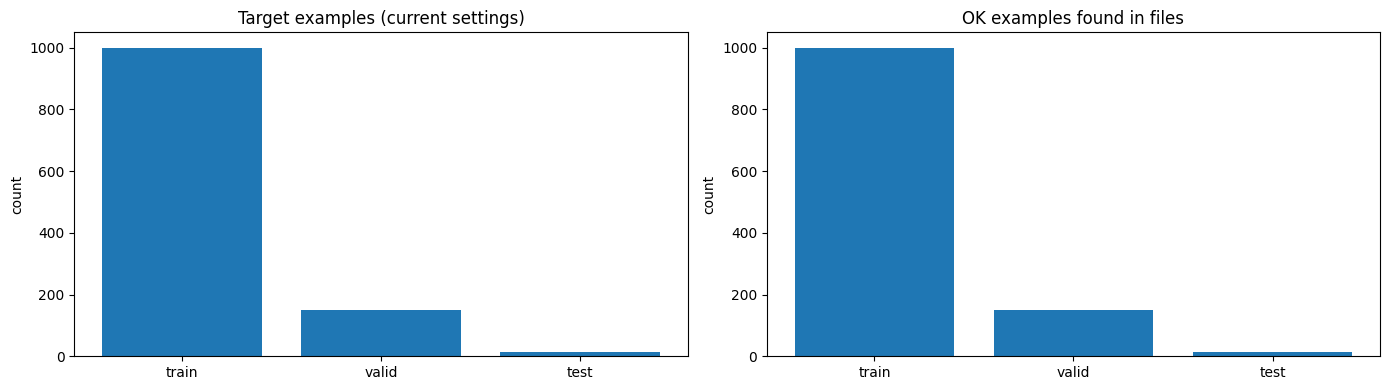

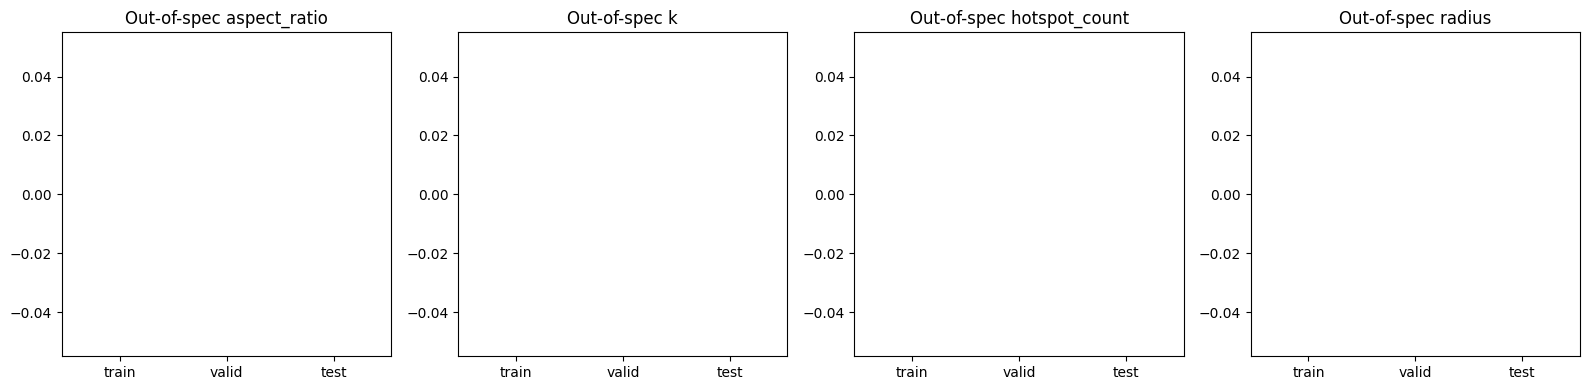

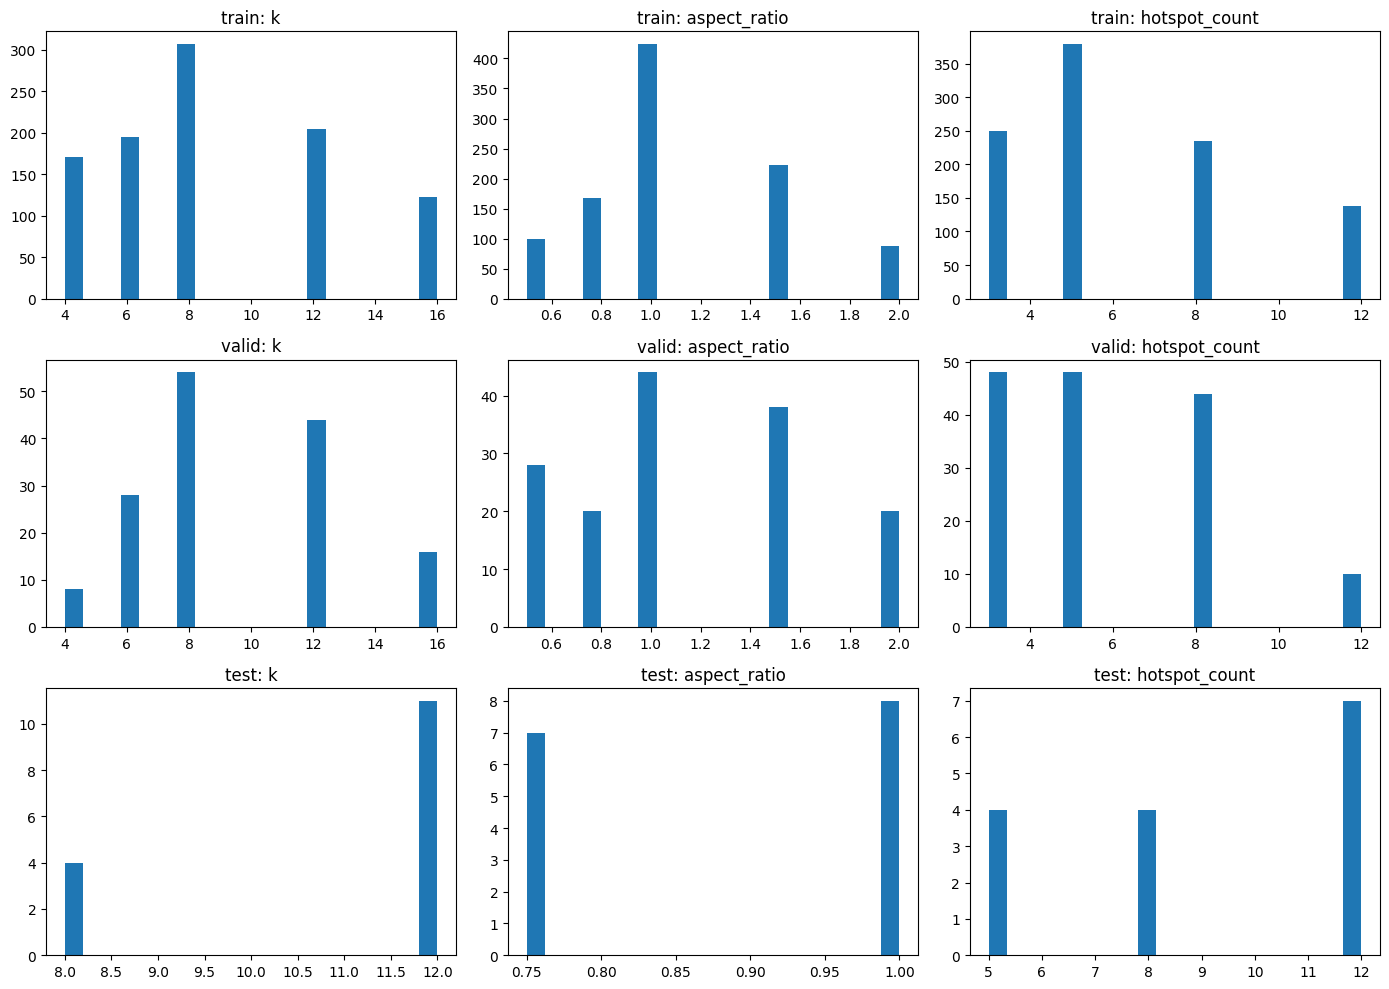

In [55]:
# Cell 1 — Validate: generation settings vs what’s inside the JSONL files (detect drift/discrepancies)

import os, json, re
from pathlib import Path
import matplotlib.pyplot as plt

# File discovery: just grab all .jsonl files in DATA_FOLDER
DATA_DIR = Path(DATA_FOLDER)
jsonl_files = sorted(DATA_DIR.glob("*.jsonl"))
if not jsonl_files:
    raise FileNotFoundError(f"No .jsonl files found under {DATA_DIR}")

def _infer_split(path: Path) -> str:
    stem = path.stem.lower()
    if stem in ("train", "training"):
        return "train"
    if stem in ("valid", "val", "validation"):
        return "valid"
    if stem in ("test", "testing"):
        return "test"
    return path.stem  # fallback label

print("JSONL files found:")
for p in jsonl_files:
    print(f"  - {_infer_split(p)}: {p}")

# Helpers
def _parse_payload_from_user(user_text: str):
    m = re.search(r"INPUT_JSON:(\{.*\})", user_text)
    if not m:
        raise ValueError("Missing INPUT_JSON")
    return json.loads(m.group(1))

def _get_var(name: str, default=None):
    return globals().get(name, default)

# Read expected settings from the notebook environment
expected = {
    "NUM_TRAIN_EXAMPLES": _get_var("NUM_TRAIN_EXAMPLES"),
    "NUM_VAL_EXAMPLES": _get_var("NUM_VAL_EXAMPLES"),
    "NUM_TEST_EXAMPLES": _get_var("NUM_TEST_EXAMPLES"),
    "ASPECT_RATIO_VALUES": _get_var("ASPECT_RATIO_VALUES"),
    "K_VALUES": _get_var("K_VALUES"),
    "HOTSPOT_COUNT_VALUES": _get_var("HOTSPOT_COUNT_VALUES"),
    "RADIUS_PROFILES": _get_var("RADIUS_PROFILES"),
}

print("\nCurrent generation settings snapshot:")
for k, v in expected.items():
    if v is None:
        print(f"  {k}: <missing>")
    elif isinstance(v, list) and len(v) > 12:
        print(f"  {k}: (len={len(v)}) {v[:6]} ...")
    else:
        print(f"  {k}: {v}")

# Allowed sets/ranges derived from current settings
allowed_ar = set(expected["ASPECT_RATIO_VALUES"] or [])
allowed_k  = set(expected["K_VALUES"] or [])
allowed_hc = set(expected["HOTSPOT_COUNT_VALUES"] or [])

radius_min = None
radius_max = None
if expected["RADIUS_PROFILES"]:
    all_ranges = [tuple(rng) for _, rng in expected["RADIUS_PROFILES"]]
    radius_min = min(r[0] for r in all_ranges)
    radius_max = max(r[1] for r in all_ranges)

# Scanner
def scan(path: str, split: str, max_lines: int | None = None):
    stats = {
        "split": split,
        "path": path,
        "lines": 0,
        "ok": 0,
        "bad_json": 0,
        "bad_schema": 0,
        "bad_centers_count": 0,
        "bad_centers_bounds": 0,
        "out_ar": 0,
        "out_k": 0,
        "out_hc": 0,
        "out_radius": 0,
        "k_vals": [],
        "ar_vals": [],
        "hc_vals": [],
    }

    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            if max_lines and i > max_lines:
                break
            stats["lines"] += 1
            try:
                obj = json.loads(line)
                msgs = obj.get("messages", None)
                if not isinstance(msgs, list) or len(msgs) < 2:
                    stats["bad_schema"] += 1
                    continue

                payload = _parse_payload_from_user(msgs[0]["content"])
                out = json.loads(msgs[1]["content"])

                k = int(payload.get("k"))
                ar = float(payload.get("aspect_ratio", 1.0))
                hotspots = payload.get("hotspots", [])
                hc = len(hotspots)

                centers = out.get("centers", None)
                if not isinstance(centers, list):
                    stats["bad_schema"] += 1
                    continue
                if len(centers) != k:
                    stats["bad_centers_count"] += 1
                    continue

                bounds_ok = True
                for p in centers:
                    x = float(p["x"]); y = float(p["y"])
                    if not (0.0 <= x <= 1.0 and 0.0 <= y <= 1.0):
                        stats["bad_centers_bounds"] += 1
                        bounds_ok = False
                        break
                if not bounds_ok:
                    continue

                # Drift detection vs current settings
                if allowed_ar and ar not in allowed_ar:
                    stats["out_ar"] += 1
                if allowed_k and k not in allowed_k:
                    stats["out_k"] += 1
                if allowed_hc and hc not in allowed_hc:
                    stats["out_hc"] += 1

                if radius_min is not None and radius_max is not None:
                    for hs in hotspots:
                        r = float(hs.get("radius", 0.0))
                        if not (radius_min <= r <= radius_max):
                            stats["out_radius"] += 1
                            break

                stats["ok"] += 1
                stats["k_vals"].append(k)
                stats["ar_vals"].append(ar)
                stats["hc_vals"].append(hc)

            except Exception:
                stats["bad_json"] += 1

    return stats

# Scan all .jsonl files
all_stats = [scan(str(p), _infer_split(p)) for p in jsonl_files]

# Optional: order train/valid/test first, then anything else
preferred = {"train": 0, "valid": 1, "test": 2}
all_stats.sort(key=lambda s: (preferred.get(s["split"], 99), s["split"]))

def _target_for_split(split: str):
    if split == "train": return expected["NUM_TRAIN_EXAMPLES"]
    if split == "valid": return expected["NUM_VAL_EXAMPLES"]
    if split == "test":  return expected["NUM_TEST_EXAMPLES"]
    return None

# Summary
print("\nCounts and drift summary:")
for s in all_stats:
    target = _target_for_split(s["split"])
    print(f"\n{s['split'].upper()} ({s['path']})")
    print(f"  lines={s['lines']}  target={target}  ok={s['ok']}")
    print(f"  parse/schema issues: bad_json={s['bad_json']} bad_schema={s['bad_schema']}")
    print(f"  center issues: wrong_count={s['bad_centers_count']} out_of_bounds={s['bad_centers_bounds']}")
    print(f"  drift vs current settings: out_ar={s['out_ar']} out_k={s['out_k']} out_hotspot_count={s['out_hc']} out_radius={s['out_radius']}")

# Visualize drift + distributions (quick)
labels = [s["split"] for s in all_stats]
ok_counts = [s["ok"] for s in all_stats]
targets = [_target_for_split(s["split"]) or 0 for s in all_stats]

out_ar = [s["out_ar"] for s in all_stats]
out_k  = [s["out_k"] for s in all_stats]
out_hc = [s["out_hc"] for s in all_stats]
out_r  = [s["out_radius"] for s in all_stats]

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].bar(labels, targets)
axs[0].set_title("Target examples (current settings)")
axs[0].set_ylabel("count")

axs[1].bar(labels, ok_counts)
axs[1].set_title("OK examples found in files")
axs[1].set_ylabel("count")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].bar(labels, out_ar); axs[0].set_title("Out-of-spec aspect_ratio")
axs[1].bar(labels, out_k);  axs[1].set_title("Out-of-spec k")
axs[2].bar(labels, out_hc); axs[2].set_title("Out-of-spec hotspot_count")
axs[3].bar(labels, out_r);  axs[3].set_title("Out-of-spec radius")
plt.tight_layout()
plt.show()

def _hist(ax, data, title):
    if len(data) == 0:
        ax.set_title(title + " (no data)")
        return
    ax.hist(data, bins=20)
    ax.set_title(title)

fig, axs = plt.subplots(3, 3, figsize=(14, 10))
for row_i, s in enumerate(all_stats[:3]):  # keep layout consistent; shows first 3 files
    _hist(axs[row_i, 0], s["k_vals"],  f"{s['split']}: k")
    _hist(axs[row_i, 1], s["ar_vals"], f"{s['split']}: aspect_ratio")
    _hist(axs[row_i, 2], s["hc_vals"], f"{s['split']}: hotspot_count")
plt.tight_layout()
plt.show()

Random seed = 737828827


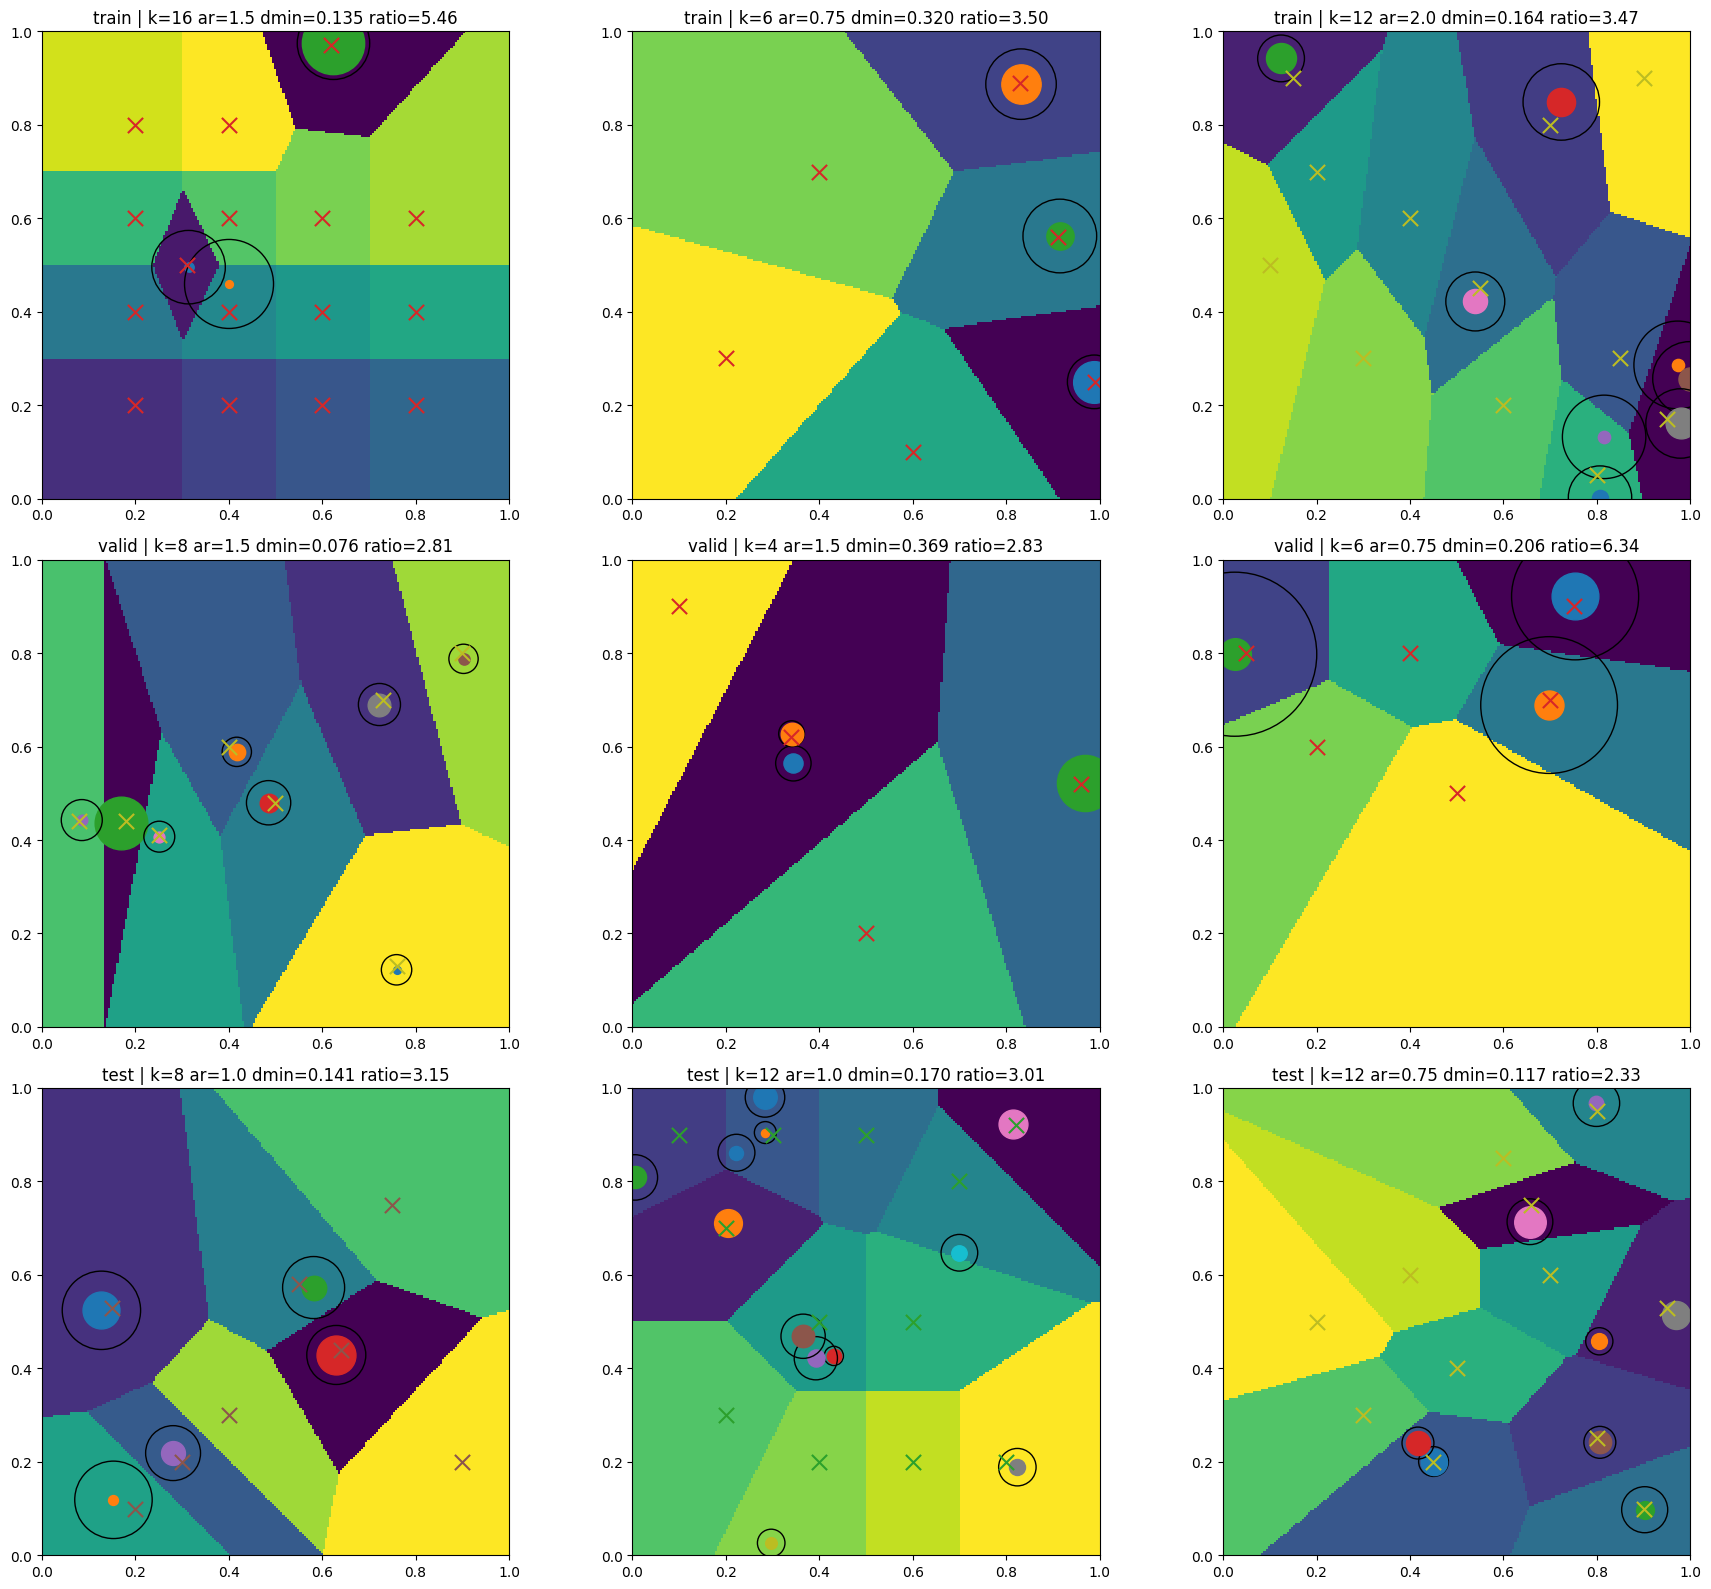

In [60]:
# Cell 2 — Visual spot-check: each run randomly picks 3 train + 3 valid + 3 test examples and plots Voronoi

import json, re, os, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

GRID_RES = 220
N_PER_SPLIT = 3

def parse_payload_from_user(user_text: str):
    m = re.search(r"INPUT_JSON:(\{.*\})", user_text)
    if not m:
        raise ValueError("Missing INPUT_JSON")
    return json.loads(m.group(1))

def voronoi_labels(centers_xy: np.ndarray, grid_res: int, aspect_ratio: float) -> np.ndarray:
    xs = np.linspace(0.0, 1.0, grid_res, dtype=float)
    ys = np.linspace(0.0, 1.0, grid_res, dtype=float)
    X, Y = np.meshgrid(xs, ys)
    pts = np.stack([X, Y], axis=-1)
    diffs = pts[..., None, :] - centers_xy[None, None, :, :]
    diffs[..., 0] *= aspect_ratio
    d2 = np.sum(diffs * diffs, axis=-1)
    return np.argmin(d2, axis=-1).astype(int)

def min_pairwise_dist(centers_xy: np.ndarray) -> float:
    if centers_xy.shape[0] < 2:
        return float("inf")
    dmin = float("inf")
    for i in range(centers_xy.shape[0]):
        d = np.linalg.norm(centers_xy[i+1:] - centers_xy[i], axis=1)
        if d.size:
            dmin = min(dmin, float(d.min()))
    return dmin

def area_ratio_from_labels(labels: np.ndarray, k: int) -> float:
    counts = np.bincount(labels.ravel(), minlength=k).astype(float)
    mn = float(counts.min())
    mx = float(counts.max())
    if mn <= 0.0:
        return float("inf")
    return mx / mn

def load_random_examples(path: str, n: int, rng: np.random.Generator):
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    n = min(n, len(lines))
    idxs = rng.choice(len(lines), size=n, replace=False)
    out = []
    for i in idxs:
        obj = json.loads(lines[i])
        payload = parse_payload_from_user(obj["messages"][0]["content"])
        resp = json.loads(obj["messages"][1]["content"])
        out.append((payload, resp))
    return out

seed = int(time.time_ns() % 2_147_483_647)
rng = np.random.default_rng(seed)
print("Random seed =", seed)

samples = [
    ("train", TRAIN_PATH, load_random_examples(TRAIN_PATH, N_PER_SPLIT, rng)),
    ("valid", VALID_PATH, load_random_examples(VALID_PATH, N_PER_SPLIT, rng)),
    ("test",  TEST_PATH,  load_random_examples(TEST_PATH,  N_PER_SPLIT, rng)),
]

fig, axs = plt.subplots(3, N_PER_SPLIT, figsize=(6*N_PER_SPLIT, 16))
if N_PER_SPLIT == 1:
    axs = np.array([[axs[0]], [axs[1]], [axs[2]]])

for r, (split, path, exs) in enumerate(samples):
    for c, (payload, resp) in enumerate(exs):
        ax = axs[r, c]
        ar = float(payload.get("aspect_ratio", 1.0))
        k = int(payload["k"])
        hotspots = payload["hotspots"]
        centers = resp["centers"]
        centers_xy = np.array([[float(p["x"]), float(p["y"])] for p in centers], dtype=float)

        labels = voronoi_labels(centers_xy, GRID_RES, ar)
        ratio = area_ratio_from_labels(labels, k)
        dmin = min_pairwise_dist(centers_xy)

        ax.imshow(labels, origin="lower", extent=(0, 1, 0, 1), interpolation="nearest")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"{split} | k={k} ar={ar} dmin={dmin:.3f} ratio={ratio:.2f}")

        for hs in hotspots:
            x, y = float(hs["x"]), float(hs["y"])
            w = float(hs["weight"])
            rad = float(hs.get("radius", 0.05))
            ax.add_patch(Circle((x, y), rad, fill=False))
            ax.scatter([x], [y], s=2000*w + 30)

        ax.scatter(centers_xy[:, 0], centers_xy[:, 1], s=120, marker="x")

plt.tight_layout()
plt.show()

# Observations and Reflection

This was perhaps a bit too ambitous for what time I had, some parts worked, others didn't.

I chose this because I'm curious on possible integration for our CSP team project AtlasNet as an experimental heuristic. later training a small model to guide servers what parts of a virtual world they are responsible for.

Initially, inputs and diversity were kept simple. But it generally yielded undesireable results, causing slim regions and giant wedges to be created from the points that were outputted.

At this point, I am largely happy with the results for how they place seeds, the data is good enough (and I don't want to spend any more $$$).

I largely failed to properly implement checkpoints for cases where there were sudden failures (closed session, no more api credits, bad network conditions, etc), and some of this code was left in.

The notebook is generally a bit messy and verbose from my experimentations. But in the interest of time, I chose to leave it as-is.


## Use of AI Tools (Academic Disclosure)

AI-assisted tools (ChatGPT-5.2) were used during the development of this notebook to:
- Pretty markdown text
- Assist in refining Python code
- Validate data

All generated content was reviewed, modified, and validated by the author.
The author retains responsibility for the correctness and originality of the final submission.